# ECG HR/HRV Pretraining — Fixed Version

Key fixes applied:
1. **Sliding-window extraction** — turns 22 records into thousands of training samples
2. **Correct `key_dim`** — set to `d_model // num_heads` (16) instead of 64
3. **Pre-LN Transformer** — more stable training
4. **Dropout** added for regularization on small dataset
5. **Cosine LR schedule** with warmup
6. **Proper evaluation** with train/val split

In [16]:
import os
import datetime
import numpy as np
import tensorflow as tf
import wfdb
import joblib

print("TF version:", tf.__version__)

TF version: 2.21.0


In [10]:
import wfdb
import os

def download_afdb_records(max_records=30, cache_dir="../../db/afdb"):
    """
    Downloads and loads full 10-hour AFDB ECG signals.
    
    - Downloads the entire AFDB database ONCE into cache_dir
    - Loads full-length signals (≈10 hours, ~9.2M samples)
    - Skips broken records gracefully
    """
    os.makedirs(cache_dir, exist_ok=True)
    print(f"Using cache directory: {cache_dir}")
    print(os.path.exists(cache_dir))
    db_name = "afdb"

    records = wfdb.get_record_list(db_name)
    print(f"Found {len(records)} records in AFDB.")
    records = records[:max_records]

    # Download database once if missing
    if not any(fname.endswith(".hea") for fname in os.listdir(cache_dir)):
        print("Downloading AFDB database (one-time)...")
        wfdb.dl_database(db_name, dl_dir=cache_dir)
        print("Download complete. Using local cache.")

    signals = []

    for rec in records:
        try:
            print(f"\n=== Loading full record {rec} ===")
            record = wfdb.rdrecord(cache_dir + "/" + rec)

            sig = record.p_signal[:, 0].astype("float32")
            print(f"Loaded {sig.shape[0]} samples ({sig.shape[0] / 250 / 3600:.2f} hours)")

            signals.append(sig)

        except Exception as e:
            print(f"Skipping {rec}: {e}")
            continue

    return signals


# Example usage:
raw_signals = download_afdb_records(max_records=30)
print("\nDownloaded", len(raw_signals), "full-length ECG signals")

import joblib
joblib.dump(raw_signals, "../../db/afdb_signals.pkl")


Using cache directory: ../../db/afdb
True
Found 25 records in AFDB.

=== Loading full record 00735 ===
Skipping 00735: sampto must be greater than sampfrom

=== Loading full record 03665 ===
Skipping 03665: sampto must be greater than sampfrom

=== Loading full record 04015 ===
Loaded 9205760 samples (10.23 hours)

=== Loading full record 04043 ===
Loaded 9205760 samples (10.23 hours)

=== Loading full record 04048 ===
Loaded 9205760 samples (10.23 hours)

=== Loading full record 04126 ===
Loaded 9205760 samples (10.23 hours)

=== Loading full record 04746 ===
Loaded 9205760 samples (10.23 hours)

=== Loading full record 04908 ===
Loaded 9205760 samples (10.23 hours)

=== Loading full record 04936 ===
Loaded 9205760 samples (10.23 hours)

=== Loading full record 05091 ===
Loaded 9205760 samples (10.23 hours)

=== Loading full record 05121 ===
Loaded 9205760 samples (10.23 hours)

=== Loading full record 05261 ===
Loaded 9205760 samples (10.23 hours)

=== Loading full record 06426 ===
L

['../../db/afdb_signals.pkl']

In [12]:
import numpy as np
import joblib
from joblib import Parallel, delayed
from scipy.signal import butter, filtfilt, find_peaks
import tensorflow as tf

# ============================================================
# 1. FAST R-PEAK DETECTOR (Pan-Tompkins style, vectorized)
# ============================================================

def bandpass_filter(ecg, fs=250, low=5, high=15):
    b, a = butter(1, [low/(fs/2), high/(fs/2)], btype='band')
    return filtfilt(b, a, ecg)

def fast_rpeak_detector(ecg, fs=250):
    x = bandpass_filter(ecg, fs)
    x2 = x * x
    win = int(0.15 * fs)
    mwa = np.convolve(x2, np.ones(win)/win, mode='same')
    peaks, _ = find_peaks(mwa, distance=int(0.25 * fs))
    return peaks

# ============================================================
# 2. HR + HRV (RMSSD) EXTRACTION with configurable window/step
# ============================================================

def fast_hr_hrv_from_rpeaks(rpeaks, fs=250, window_sec=60, step_sec=60):
    """
    Extract HR and HRV (RMSSD) from R-peaks using a sliding window.
    step_sec < window_sec creates overlapping windows = more samples.
    """
    if len(rpeaks) < 3:
        return None, None

    rr_intervals = np.diff(rpeaks) / fs
    rr_intervals = rr_intervals[(rr_intervals > 0.3) & (rr_intervals < 2.0)]

    if len(rr_intervals) < 3:
        return None, None

    rr_times = rpeaks[1:len(rr_intervals)+1] / fs
    t_max = rr_times[-1]
    times = np.arange(0, t_max - window_sec + 1, step_sec)

    hr = np.full(len(times), np.nan, dtype="float32")
    hrv = np.full(len(times), np.nan, dtype="float32")

    for i, t0 in enumerate(times):
        t1 = t0 + window_sec
        mask = (rr_times >= t0) & (rr_times < t1)
        if np.sum(mask) < 3:
            continue
        rr_win = rr_intervals[mask]
        hr_val = 60.0 / np.mean(rr_win)
        if 30 <= hr_val <= 220:
            hr[i] = hr_val
        diff_rr = np.diff(rr_win)
        if len(diff_rr) > 0:
            hrv[i] = np.sqrt(np.mean(diff_rr**2))

    valid = ~np.isnan(hr)
    if np.sum(valid) < 10:
        return None, None

    return hr[valid], hrv[valid]

def extract_hr_hrv_fast(ecg, fs=250):
    rpeaks = fast_rpeak_detector(ecg, fs)
    return fast_hr_hrv_from_rpeaks(rpeaks, fs)

# ============================================================
# 3. SLIDING WINDOW: extract many fixed-length subsequences
#    from each record's HR/HRV time series.
#    This is the KEY fix — turns 22 records into many samples.
# ============================================================

T = 128           # sequence length (minutes) — shorter = more samples
STEP = 32         # step size between windows — smaller = more overlap = more samples

def extract_windows(hr_seq, hrv_seq, T=128, step=32):
    """Slice a HR/HRV time series into fixed-length windows."""
    windows_hr, windows_hrv = [], []
    n = len(hr_seq)
    for start in range(0, n - T + 1, step):
        windows_hr.append(hr_seq[start:start+T])
        windows_hrv.append(hrv_seq[start:start+T])
    return windows_hr, windows_hrv

# ============================================================
# 4. LOAD & PROCESS
# ============================================================

raw_signals = joblib.load("../../db/afdb_signals.pkl")
print("Loaded raw signals:", len(raw_signals))

# Extract HR/HRV per record (in parallel)
results = Parallel(n_jobs=-1)(
    delayed(extract_hr_hrv_fast)(sig) for sig in raw_signals
)

# Slice into windows
hr_list, hrv_list = [], []
for hr, hrv in results:
    if hr is None:
        continue
    wins_hr, wins_hrv = extract_windows(hr, hrv, T=T, step=STEP)
    hr_list.extend(wins_hr)
    hrv_list.extend(wins_hrv)

hr_arr  = np.array(hr_list,  dtype="float32")   # (N, T)
hrv_arr = np.array(hrv_list, dtype="float32")   # (N, T)

# Activity is still zeros (placeholder for future wearable data)
activity_arr = np.zeros((hr_arr.shape[0], hr_arr.shape[1], 3), dtype="float32")

print(f"Total windows: {hr_arr.shape[0]}  (seq_len={T})")

# ============================================================
# 5. IMPUTE NaNs
# ============================================================

def impute_nan(arr):
    m = np.nanmean(arr, axis=1, keepdims=True)
    return np.where(np.isnan(arr), m, arr)

hr_arr  = impute_nan(hr_arr)
hrv_arr = impute_nan(hrv_arr)

print("HR shape:", hr_arr.shape, "  HRV shape:", hrv_arr.shape)
print(f"HR  range: [{hr_arr.min():.1f}, {hr_arr.max():.1f}]  mean={hr_arr.mean():.1f}")
print(f"HRV range: [{hrv_arr.min():.4f}, {hrv_arr.max():.4f}]  mean={hrv_arr.mean():.4f}")

Loaded raw signals: 23
Total windows: 177  (seq_len=128)
HR shape: (177, 128)   HRV shape: (177, 128)
HR  range: [105.6, 195.5]  mean=150.7
HRV range: [0.0033, 0.2253]  mean=0.1023


In [13]:
# ============================================================
# 6. TRAIN / VAL SPLIT
# ============================================================

N = hr_arr.shape[0]
idx = np.random.permutation(N)
split = int(0.85 * N)
train_idx, val_idx = idx[:split], idx[split:]

hr_train,  hrv_train,  act_train  = hr_arr[train_idx],  hrv_arr[train_idx],  activity_arr[train_idx]
hr_val,    hrv_val,    act_val    = hr_arr[val_idx],    hrv_arr[val_idx],    activity_arr[val_idx]

print(f"Train: {hr_train.shape[0]}  |  Val: {hr_val.shape[0]}")

# ============================================================
# 7. TF DATASET WITH MASKING
# ============================================================

BATCH_SIZE = 32
MASK_RATIO = 0.15

def make_ds(hr, hrv, activity, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices(
        {"hr": hr, "hrv": hrv, "activity": activity}
    )
    if shuffle:
        ds = ds.shuffle(2048)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

def add_mask(batch, mask_ratio=MASK_RATIO):
    hr = batch["hr"]
    mask = tf.cast(tf.random.uniform(tf.shape(hr)) < mask_ratio, tf.float32)
    batch["hr_masked"] = hr * (1.0 - mask)
    batch["mask"] = mask
    return batch

def map_to_model_inputs(batch):
    inputs = {
        "hr_in":       batch["hr_masked"],
        "hrv_in":      batch["hrv"],
        "activity_in": batch["activity"],
    }
    y  = batch["hr"]
    sw = tf.expand_dims(batch["mask"], axis=-1)   # sample_weight needs trailing dim
    return (inputs, y, sw)

train_ds = make_ds(hr_train, hrv_train, act_train, shuffle=True ).map(add_mask).map(map_to_model_inputs)
val_ds   = make_ds(hr_val,   hrv_val,   act_val,   shuffle=False).map(add_mask).map(map_to_model_inputs)

Train: 150  |  Val: 27


W0000 00:00:1775315187.997620  151519 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1775315188.002710  151519 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1775315188.684089  151519 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9226 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070 Ti Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 12.0a


In [14]:
# ============================================================
# 8. MODEL — Pre-LN Transformer with fixed key_dim
#
#  Fixes vs original:
#    * key_dim = d_model // num_heads  (was wrongly set to d_model)
#    * Pre-LN (LayerNorm BEFORE attention/FFN) — more stable
#    * Dropout added for regularisation
# ============================================================

def transformer_block_pre_ln(x, d_model, num_heads, dropout_rate=0.1):
    """Pre-LN Transformer block: LN → Attn → Add → LN → FFN → Add"""
    key_dim = d_model // num_heads   # FIX: was d_model (64) — now 16

    # Self-attention sub-layer
    x_ln = tf.keras.layers.LayerNormalization()(x)
    attn = tf.keras.layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=key_dim,
        dropout=dropout_rate,
    )(x_ln, x_ln)
    attn = tf.keras.layers.Dropout(dropout_rate)(attn)
    x = tf.keras.layers.Add()([x, attn])

    # Feed-forward sub-layer
    x_ln = tf.keras.layers.LayerNormalization()(x)
    ff = tf.keras.layers.Dense(d_model * 4, activation="gelu")(x_ln)
    ff = tf.keras.layers.Dropout(dropout_rate)(ff)
    ff = tf.keras.layers.Dense(d_model)(ff)
    ff = tf.keras.layers.Dropout(dropout_rate)(ff)
    x = tf.keras.layers.Add()([x, ff])

    return x


def build_encoder(seq_len=128, d_model=64, num_heads=4, num_layers=3, dropout_rate=0.1):
    inputs = {
        "hr":       tf.keras.Input(shape=(seq_len,),    name="hr"),
        "hrv":      tf.keras.Input(shape=(seq_len,),    name="hrv"),
        "activity": tf.keras.Input(shape=(seq_len, 3),  name="activity"),
    }

    # Normalise inputs
    hr_norm  = tf.keras.layers.Normalization(axis=None, name="hr_norm")
    hrv_norm = tf.keras.layers.Normalization(axis=None, name="hrv_norm")
    x_hr  = tf.keras.layers.Reshape((seq_len, 1))(hr_norm(inputs["hr"]))
    x_hrv = tf.keras.layers.Reshape((seq_len, 1))(hrv_norm(inputs["hrv"]))

    # Concatenate all features: (B, T, 5)
    x = tf.keras.layers.Concatenate(axis=-1)([x_hr, x_hrv, inputs["activity"]])

    # Project to d_model
    x = tf.keras.layers.Dense(d_model)(x)

    # Positional encoding
    pos = tf.keras.layers.Embedding(input_dim=seq_len, output_dim=d_model)(tf.range(seq_len))
    x = x + pos

    x = tf.keras.layers.Dropout(dropout_rate)(x)

    # Transformer blocks (Pre-LN)
    for _ in range(num_layers):
        x = transformer_block_pre_ln(x, d_model, num_heads, dropout_rate)

    # Final LayerNorm (Pre-LN style)
    x = tf.keras.layers.LayerNormalization()(x)

    model = tf.keras.Model(inputs=inputs, outputs=x, name="ts_encoder")
    return model


SEQ_LEN = T   # match the window size chosen above
encoder = build_encoder(seq_len=SEQ_LEN)

# Adapt normalization layers to training data statistics
encoder.get_layer("hr_norm" ).adapt(hr_train)
encoder.get_layer("hrv_norm").adapt(hrv_train)

# Build pretraining head: predict original HR from masked HR
enc_inputs = {
    "hr":       tf.keras.Input(shape=(SEQ_LEN,),   name="hr_in"),
    "hrv":      tf.keras.Input(shape=(SEQ_LEN,),   name="hrv_in"),
    "activity": tf.keras.Input(shape=(SEQ_LEN, 3), name="activity_in"),
}
enc_out  = encoder({"hr": enc_inputs["hr"], "hrv": enc_inputs["hrv"], "activity": enc_inputs["activity"]})
x        = tf.keras.layers.Dense(64, activation="gelu")(enc_out)
hr_pred  = tf.keras.layers.Dense(1)(x)
hr_pred  = tf.keras.layers.Reshape((SEQ_LEN,))(hr_pred)

pretrain_model = tf.keras.Model(
    inputs=[enc_inputs["hr"], enc_inputs["hrv"], enc_inputs["activity"]],
    outputs=hr_pred,
)

encoder.summary()

Model: "ts_encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ hr (InputLayer)     │ (None, 128)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hrv (InputLayer)    │ (None, 128)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hr_norm             │ (None, 128)       │          3 │ hr[0][0]          │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hrv_norm            │ (None, 128)       │          3 │ hrv[0][0]         │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 128, 1)    │          0 │ hr_norm[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 128, 1)    │          0 │ hrv_norm[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activity            │ (None, 128, 3)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 128, 5)    │          0 │ reshape[0][0],    │
│ (Concatenate)       │                   │            │ reshape_1[0][0],  │
│                     │                   │            │ activity[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128, 64)   │        384 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 128, 64)   │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128, 64)   │          0 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 128, 64)   │        128 │ dropout[0][0]     │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 128, 64)   │     16,640 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128, 64)   │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 128, 64)   │          0 │ dropout[0][0],    │
│                     │                   │            │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 128, 64)   │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128, 256)  │     16,640 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 128, 256)  │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128, 64)   │     16,448 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 128, 64)   │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 150,470 (587.78 KB)

 Trainable params: 150,464 (587.75 KB)

 Non-trainable params: 6 (32.00 B)

In [20]:
# ============================================================
# 9. TRAINING WITH COSINE LR SCHEDULE + EARLY STOPPING
# ============================================================

EPOCHS     = 200
STEPS_TRAIN = len(hr_train) // BATCH_SIZE

# Cosine decay with linear warmup
class WarmupCosineDecay(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, init_lr, warmup_steps, total_steps):
        super().__init__()
        self.init_lr       = init_lr
        self.warmup_steps  = tf.cast(warmup_steps,  tf.float32)
        self.total_steps   = tf.cast(total_steps,   tf.float32)

    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        warmup_lr = self.init_lr * (step / self.warmup_steps)
        cosine_lr = self.init_lr * 0.5 * (
            1.0 + tf.math.cos(
                np.pi * (step - self.warmup_steps) / (self.total_steps - self.warmup_steps)
            )
        )
        return tf.where(step < self.warmup_steps, warmup_lr, cosine_lr)

    def get_config(self):
        return {"init_lr": self.init_lr,
                "warmup_steps": int(self.warmup_steps.numpy()),
                "total_steps":  int(self.total_steps.numpy())}

class R2Score(tf.keras.metrics.Metric):
    def __init__(self, name="r2", **kwargs):
        super().__init__(name=name, **kwargs)
        self.sse = self.add_weight(name="sse", initializer="zeros")
        self.sst = self.add_weight(name="sst", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)

        self.sse.assign_add(tf.reduce_sum(tf.square(y_true - y_pred)))
        self.sst.assign_add(tf.reduce_sum(tf.square(y_true - tf.reduce_mean(y_true))))

    def result(self):
        return 1 - (self.sse / (self.sst + 1e-8))

    def reset_state(self):
        self.sse.assign(0.0)
        self.sst.assign(0.0)

total_steps  = EPOCHS * STEPS_TRAIN
warmup_steps = 5 * STEPS_TRAIN

lr_schedule = WarmupCosineDecay(init_lr=3e-4, warmup_steps=warmup_steps, total_steps=total_steps)

pretrain_model.compile(
    optimizer=tf.keras.optimizers.Adam(lr_schedule),
    loss=tf.keras.losses.MeanSquaredError(),
    metrics=[
        tf.keras.metrics.MeanAbsoluteError(name="mae"),
        tf.keras.metrics.MeanAbsolutePercentageError(name="mape"),
        tf.keras.metrics.RootMeanSquaredError(name="rmse"),
        R2Score(),
    ]
)

log_dir = os.path.join("logs", "pretrain", datetime.datetime.now().strftime("%Y%m%d-%H%M%S"), "final")
callbacks = [
    tf.keras.callbacks.TensorBoard(log_dir=log_dir),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=20, restore_best_weights=True, verbose=1
    ),
]

history = pretrain_model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=callbacks,
)

Epoch 1/200


I0000 00:00:1775315578.062811  164400 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_103468__.133


3/5 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 83.8244 - mae: 21.8751 - mape: 14.1849 - r2: -5.0719 - rmse: 23.8334

I0000 00:00:1775315591.456311  164399 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_103468__.133


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - loss: 83.9337 - mae: 21.7651 - mape: 14.1110 - r2: -4.7684 - rmse: 23.7984  

I0000 00:00:1775315604.896293  164397 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_104670__.32


5/5 ━━━━━━━━━━━━━━━━━━━━ 38s 4s/step - loss: 83.3676 - mae: 21.6566 - mape: 14.0380 - r2: -4.4000 - rmse: 23.7584 - val_loss: 91.2414 - val_mae: 21.7446 - val_mape: 13.8868 - val_r2: -3.4087 - val_rmse: 24.2324
Epoch 2/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 82.8143 - mae: 21.2061 - mape: 13.7406 - r2: -4.2033 - rmse: 23.3300 - val_loss: 81.3045 - val_mae: 20.9591 - val_mape: 13.3749 - val_r2: -3.1446 - val_rmse: 23.4955
Epoch 3/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 75.3547 - mae: 20.1887 - mape: 13.0671 - r2: -3.8793 - rmse: 22.3980 - val_loss: 71.0280 - val_mae: 19.6279 - val_mape: 12.5093 - val_r2: -2.7157 - val_rmse: 22.2465
Epoch 4/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 67.3478 - mae: 18.6117 - mape: 12.0268 - r2: -3.2431 - rmse: 20.9368 - val_loss: 65.4618 - val_mae: 17.8116 - val_mape: 11.3327 - val_r2: -2.1689 - val_rmse: 20.5446
Epoch 5/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 55.0049 - mae: 16.5670 - mape: 10.6832 - r2: -2.5094 - rmse

In [23]:
encoder.save("../../models/encoder_pretrained.h5")
print("Encoder saved to encoder_pretrained.h5")

np.savez(
    "../../db/hr_data_windows.npz",
    hr_arr=hr_arr,
    hrv_arr=hrv_arr,
    activity_arr=activity_arr,
)
print("Saved hr_data_windows.npz")

Encoder saved to encoder_pretrained.h5
Saved hr_data_windows.npz


I0000 00:00:1775315641.063084  164398 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_161048__.21


Validation Masked MAE: 5.8003 BPM
(HR mean=150.7  std=10.5)


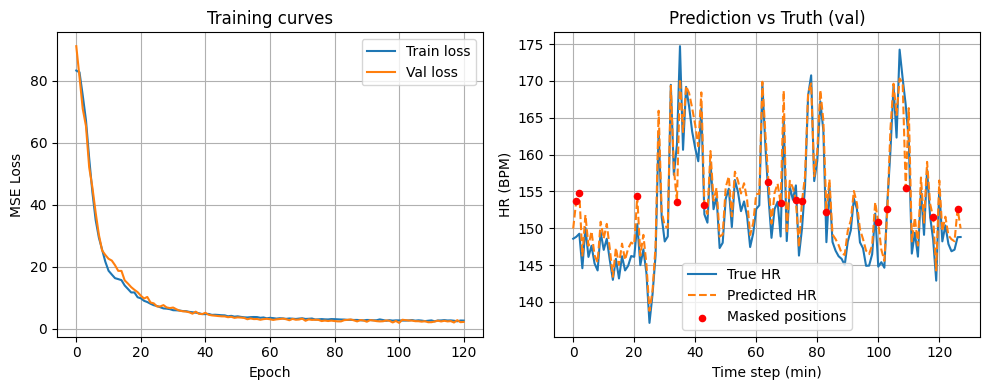

Plot saved to pretrain_results.png


In [21]:
# ============================================================
# 11. EVALUATE — Masked MAE on validation set
# ============================================================

import matplotlib.pyplot as plt

all_mae = []
for x_batch, y_true_batch, sw_batch in val_ds:
    y_pred_batch = pretrain_model.predict(x_batch, verbose=0)
    y_pred_batch = tf.convert_to_tensor(y_pred_batch)
    sw_squeezed  = tf.squeeze(sw_batch, axis=-1)
    mae = tf.reduce_sum(
        tf.abs(y_pred_batch - y_true_batch) * sw_squeezed
    ) / (tf.reduce_sum(sw_squeezed) + 1e-6)
    all_mae.append(mae.numpy())

print(f"Validation Masked MAE: {np.mean(all_mae):.4f} BPM")
print(f"(HR mean={hr_arr.mean():.1f}  std={hr_arr.std():.1f})")

# ── Training curves ──────────────────────────────────────────
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history["loss"],     label="Train loss")
plt.plot(history.history["val_loss"], label="Val loss")
plt.xlabel("Epoch"); plt.ylabel("MSE Loss")
plt.title("Training curves"); plt.legend(); plt.grid(True)

# ── Prediction vs ground truth on one validation batch ───────
for x_batch, y_true_batch, sw_batch in val_ds.take(1):
    y_pred_batch = pretrain_model.predict(x_batch, verbose=0)
    sw_squeezed  = sw_batch.numpy().squeeze(-1)[0].astype(bool)
    y_true_seq   = y_true_batch.numpy()[0]
    y_pred_seq   = y_pred_batch[0]

plt.subplot(1, 2, 2)
t = np.arange(SEQ_LEN)
plt.plot(t, y_true_seq,              label="True HR",       linewidth=1.5)
plt.plot(t, y_pred_seq, '--',        label="Predicted HR",  linewidth=1.5)
plt.scatter(t[sw_squeezed], y_pred_seq[sw_squeezed],
            c='red', s=20, zorder=5, label="Masked positions")
plt.xlabel("Time step (min)"); plt.ylabel("HR (BPM)")
plt.title("Prediction vs Truth (val)"); plt.legend(); plt.grid(True)

plt.tight_layout()
plt.savefig("pretrain_results.png", dpi=120)
plt.show()
print("Plot saved to pretrain_results.png")

In [22]:
# ============================================================
# MAE CALCULATION — per masked position, across full val set
# ============================================================

all_abs_errors = []

for x_batch, y_true_batch, sw_batch in val_ds:
    y_pred_batch = pretrain_model.predict(x_batch, verbose=0)
    y_pred_batch = tf.convert_to_tensor(y_pred_batch)
    sw_squeezed  = tf.squeeze(sw_batch, axis=-1)

    # Only count masked positions
    abs_errors = tf.abs(y_pred_batch - y_true_batch) * sw_squeezed
    all_abs_errors.append(abs_errors.numpy().flatten())

all_abs_errors = np.concatenate(all_abs_errors)

# Remove zeros (unmasked positions)
masked_errors = all_abs_errors[all_abs_errors > 0]

print(f"Masked MAE:    {masked_errors.mean():.3f} BPM")
print(f"Masked Median: {np.median(masked_errors):.3f} BPM")
print(f"Masked Std:    {masked_errors.std():.3f} BPM")
print(f"Masked 90th p: {np.percentile(masked_errors, 90):.3f} BPM")
print(f"Total masked positions evaluated: {len(masked_errors)}")
print(f"HR range in data: [{hr_arr.min():.1f}, {hr_arr.max():.1f}] BPM")

Masked MAE:    5.386 BPM
Masked Median: 3.878 BPM
Masked Std:    5.529 BPM
Masked 90th p: 11.792 BPM
Total masked positions evaluated: 502
HR range in data: [105.6, 195.5] BPM
